In [1]:
# GRIDSENSE LOAD FORECASTING SYSTEM

In [2]:
# IMPORTING LIBRARIES

import os
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler, MinMaxScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
## SETTING UP PATHS

import os


DATA_PATH = r"C:\\Users\\vedan\\Downloads\\datasets\\electricity_load.csv"

MODEL_DIR = "../models"
OUTPUT_DIR = "../outputs"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Model directory:", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)

Model directory: ../models
Output directory: ../outputs


In [4]:
# 2 LOADING DATASET

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head(11)

Dataset loaded successfully.
Shape: (48048, 17)


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,03-01-2015 01:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,03-01-2015 02:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,03-01-2015 03:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,03-01-2015 04:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,03-01-2015 05:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0
5,03-01-2015 06:00,879.2323,26.034143,0.019080,0.014542,20.062038,22.995081,0.017028,0.001485,9.087273,22.456018,0.016410,0.061539,5.280351,0,0,0
6,03-01-2015 07:00,932.4876,26.691492,0.019332,0.006645,21.623496,24.285242,0.017424,0.002176,11.395393,22.949304,0.016570,0.060898,5.126911,0,0,0
7,03-01-2015 08:00,1048.9720,27.674066,0.019370,0.006863,23.775317,26.189691,0.018073,0.004539,12.872866,24.088129,0.016677,0.056198,5.060611,0,0,0
8,03-01-2015 09:00,1167.9074,28.760400,0.019171,0.010231,24.636152,27.916650,0.018454,0.004292,14.548027,25.479150,0.016646,0.051071,4.915658,0,0,0
9,03-01-2015 10:00,1257.5069,29.766656,0.018759,0.009018,25.862671,29.172906,0.018675,0.004921,15.081688,26.704156,0.016608,0.058685,4.685580,0,0,0


In [5]:
# 3 COLUMNS 
print("Columns:")
for i, column in enumerate(df.columns):
    print(i, "->", column)

Columns:
0 -> datetime
1 -> nat_demand
2 -> T2M_toc
3 -> QV2M_toc
4 -> TQL_toc
5 -> W2M_toc
6 -> T2M_san
7 -> QV2M_san
8 -> TQL_san
9 -> W2M_san
10 -> T2M_dav
11 -> QV2M_dav
12 -> TQL_dav
13 -> W2M_dav
14 -> Holiday_ID
15 -> holiday
16 -> school


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48048 entries, 0 to 48047
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    48048 non-null  object 
 1   nat_demand  48048 non-null  float64
 2   T2M_toc     48048 non-null  float64
 3   QV2M_toc    48048 non-null  float64
 4   TQL_toc     48048 non-null  float64
 5   W2M_toc     48048 non-null  float64
 6   T2M_san     48048 non-null  float64
 7   QV2M_san    48048 non-null  float64
 8   TQL_san     48048 non-null  float64
 9   W2M_san     48048 non-null  float64
 10  T2M_dav     48048 non-null  float64
 11  QV2M_dav    48048 non-null  float64
 12  TQL_dav     48048 non-null  float64
 13  W2M_dav     48048 non-null  float64
 14  Holiday_ID  48048 non-null  int64  
 15  holiday     48048 non-null  int64  
 16  school      48048 non-null  int64  
dtypes: float64(13), int64(3), object(1)
memory usage: 6.2+ MB


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
datetime,48048,48048,03-01-2015 01:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nat_demand,48048.0,NaN,NaN,NaN,1182.868647,192.068896,85.1925,1020.0569,1168.4277,1327.56395,1754.882
T2M_toc,48048.0,NaN,NaN,NaN,27.399111,1.675462,22.953455,26.160455,27.118051,28.558344,35.039575
QV2M_toc,48048.0,NaN,NaN,NaN,0.018313,0.001607,0.012054,0.017236,0.01859,0.019521,0.02269
TQL_toc,48048.0,NaN,NaN,NaN,0.079979,0.065589,0.0,0.026451,0.065201,0.11731,0.52124
W2M_toc,48048.0,NaN,NaN,NaN,13.391049,7.295502,0.008979,7.544958,12.182103,18.661282,39.229726
T2M_san,48048.0,NaN,NaN,NaN,26.921023,3.018129,19.765222,24.769281,26.167352,28.712335,39.06344
QV2M_san,48048.0,NaN,NaN,NaN,0.017844,0.001889,0.010247,0.016584,0.018351,0.019242,0.022165
TQL_san,48048.0,NaN,NaN,NaN,0.106265,0.086293,0.000009,0.036819,0.085968,0.157288,0.484985
W2M_san,48048.0,NaN,NaN,NaN,7.046675,4.103711,0.060394,3.955051,5.992762,9.409871,24.483937


In [8]:
# 4 CHECKING FOR MISSING VALUES
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": (
        missing_values / len(df) * 100
    )
})

missing_table.sort_values(
    "Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
datetime,0,0.0
nat_demand,0,0.0
T2M_toc,0,0.0
QV2M_toc,0,0.0
TQL_toc,0,0.0
W2M_toc,0,0.0
T2M_san,0,0.0
QV2M_san,0,0.0
TQL_san,0,0.0
W2M_san,0,0.0


In [9]:
# check for duplicates
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [10]:
# checking to indax
print("Index type:")
print(type(df.index))

print("\nIndex:")
print(df.index)

print("\nIndex name:")
print(df.index.name)

Index type:
<class 'pandas.core.indexes.range.RangeIndex'>

Index:
RangeIndex(start=0, stop=48048, step=1)

Index name:
None


In [11]:
# possible datetime columns 
possible_datetime_columns = []

for column in df.columns:
    try:
        converted = pd.to_datetime(
            df[column],
            errors="coerce"
        )

        valid_ratio = converted.notna().mean()

        if valid_ratio > 0.8:
            possible_datetime_columns.append(
                (column, valid_ratio)
            )

    except Exception:
        pass

print("Possible datetime columns:")

for item in possible_datetime_columns:
    print(item)

Possible datetime columns:
('nat_demand', np.float64(1.0))
('T2M_toc', np.float64(1.0))
('QV2M_toc', np.float64(1.0))
('TQL_toc', np.float64(1.0))
('W2M_toc', np.float64(1.0))
('T2M_san', np.float64(1.0))
('QV2M_san', np.float64(1.0))
('TQL_san', np.float64(1.0))
('W2M_san', np.float64(1.0))
('T2M_dav', np.float64(1.0))
('QV2M_dav', np.float64(1.0))
('TQL_dav', np.float64(1.0))
('W2M_dav', np.float64(1.0))
('Holiday_ID', np.float64(1.0))
('holiday', np.float64(1.0))
('school', np.float64(1.0))


In [12]:
print(df.head(10).to_string())

           datetime  nat_demand    T2M_toc  QV2M_toc   TQL_toc    W2M_toc    T2M_san  QV2M_san   TQL_san    W2M_san    T2M_dav  QV2M_dav   TQL_dav   W2M_dav  Holiday_ID  holiday  school
0  03-01-2015 01:00    970.3450  25.865259  0.018576  0.016174  21.850546  23.482446  0.017272  0.001855  10.328949  22.662134  0.016562  0.096100  5.364148           0        0       0
1  03-01-2015 02:00    912.1755  25.899255  0.018653  0.016418  22.166944  23.399255  0.017265  0.001327  10.681517  22.578943  0.016509  0.087646  5.572471           0        0       0
2  03-01-2015 03:00    900.2688  25.937280  0.018768  0.015480  22.454911  23.343530  0.017211  0.001428  10.874924  22.531030  0.016479  0.078735  5.871184           0        0       0
3  03-01-2015 04:00    889.9538  25.957544  0.018890  0.016273  22.110481  23.238794  0.017128  0.002599  10.518620  22.512231  0.016487  0.068390  5.883621           0        0       0
4  03-01-2015 05:00    893.6865  25.973840  0.018981  0.017281  21.186

In [14]:
print(df.index[:10])

RangeIndex(start=0, stop=10, step=1)


In [16]:
# Data Cleaning and Preprocessing

TARGET = "nat_demand"

if TARGET not in df.columns:
    raise ValueError(
        f"{TARGET} was not found in the dataset."
    )

print("Target variable:", TARGET)


Target variable: nat_demand


In [17]:
# Feature & weather columns
FEATURES = [
    "T2M_toc",
    "QV2M_toc",
    "TQL_toc",
    "W2M_toc",

    "T2M_san",
    "QV2M_san",
    "TQL_san",
    "W2M_san",

    "T2M_dav",
    "QV2M_dav",
    "TQL_dav",
    "W2M_dav",

    "Holiday_ID",
    "holiday",
    "school"
]

missing_features = [
    feature
    for feature in FEATURES
    if feature not in df.columns
]

if missing_features:
    print("Missing features:", missing_features)
else:
    print("All expected features are available.")

All expected features are available.


In [18]:
# neumric check 
print(
    df[
        [TARGET] + FEATURES
    ].dtypes
)

nat_demand    float64
T2M_toc       float64
QV2M_toc      float64
TQL_toc       float64
W2M_toc       float64
T2M_san       float64
QV2M_san      float64
TQL_san       float64
W2M_san       float64
T2M_dav       float64
QV2M_dav      float64
TQL_dav       float64
W2M_dav       float64
Holiday_ID      int64
holiday         int64
school          int64
dtype: object


In [19]:
# convert to numeric

for column in [TARGET] + FEATURES:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print(df[[TARGET] + FEATURES].dtypes)

nat_demand    float64
T2M_toc       float64
QV2M_toc      float64
TQL_toc       float64
W2M_toc       float64
T2M_san       float64
QV2M_san      float64
TQL_san       float64
W2M_san       float64
T2M_dav       float64
QV2M_dav      float64
TQL_dav       float64
W2M_dav       float64
Holiday_ID      int64
holiday         int64
school          int64
dtype: object


In [20]:
# Handling Missing Values

numeric_columns = [TARGET] + FEATURES

df[numeric_columns] = (
    df[numeric_columns]
    .interpolate(method="linear")
    .ffill()
    .bfill()
)

print(
    "Remaining missing values:",
    df[numeric_columns].isnull().sum().sum()
)

Remaining missing values: 0


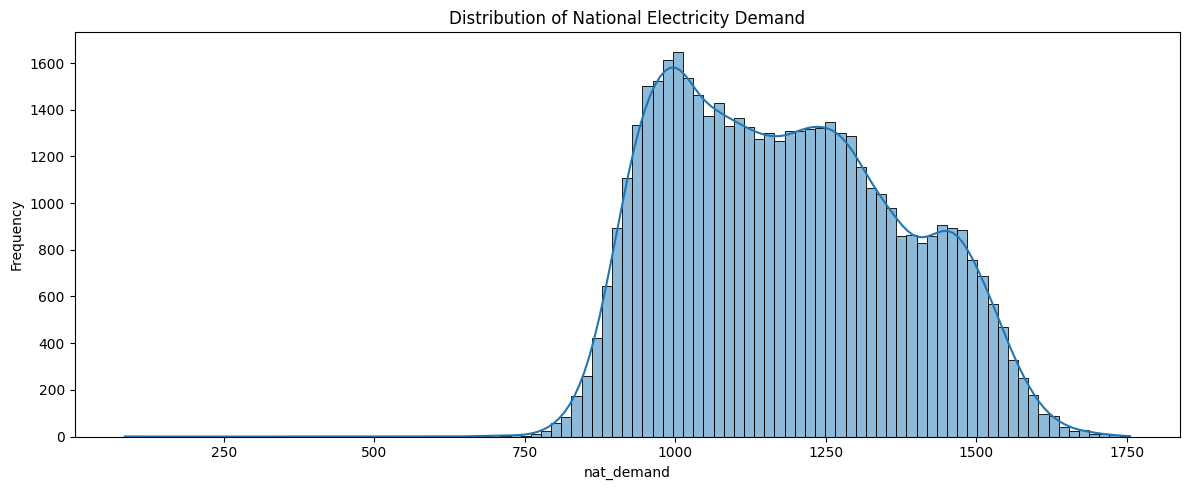

In [21]:
# Distribution of Target Variable
plt.figure(figsize=(12, 5))

sns.histplot(
    df[TARGET],
    kde=True
)

plt.title("Distribution of National Electricity Demand")
plt.xlabel("nat_demand")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [22]:
# Mathematical Summary of Target Variable
print("Minimum demand:", df[TARGET].min())
print("Maximum demand:", df[TARGET].max())
print("Mean demand:", df[TARGET].mean())
print("Median demand:", df[TARGET].median())
print("Standard deviation:", df[TARGET].std())

Minimum demand: 85.1925
Maximum demand: 1754.882
Mean demand: 1182.8686472324282
Median demand: 1168.4277
Standard deviation: 192.06889632627528


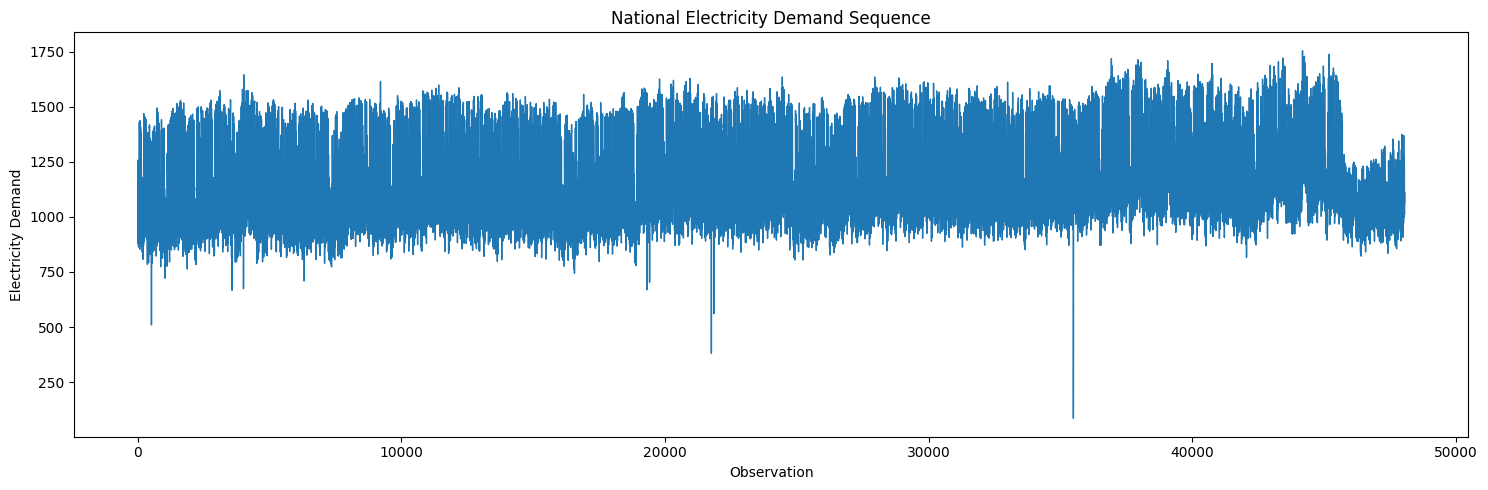

In [23]:
# Exploratory Data Analysic

plt.figure(figsize=(15, 5))

plt.plot(
    df[TARGET].values,
    linewidth=1
)

plt.title("National Electricity Demand Sequence")
plt.xlabel("Observation")
plt.ylabel("Electricity Demand")

plt.tight_layout()
plt.show()

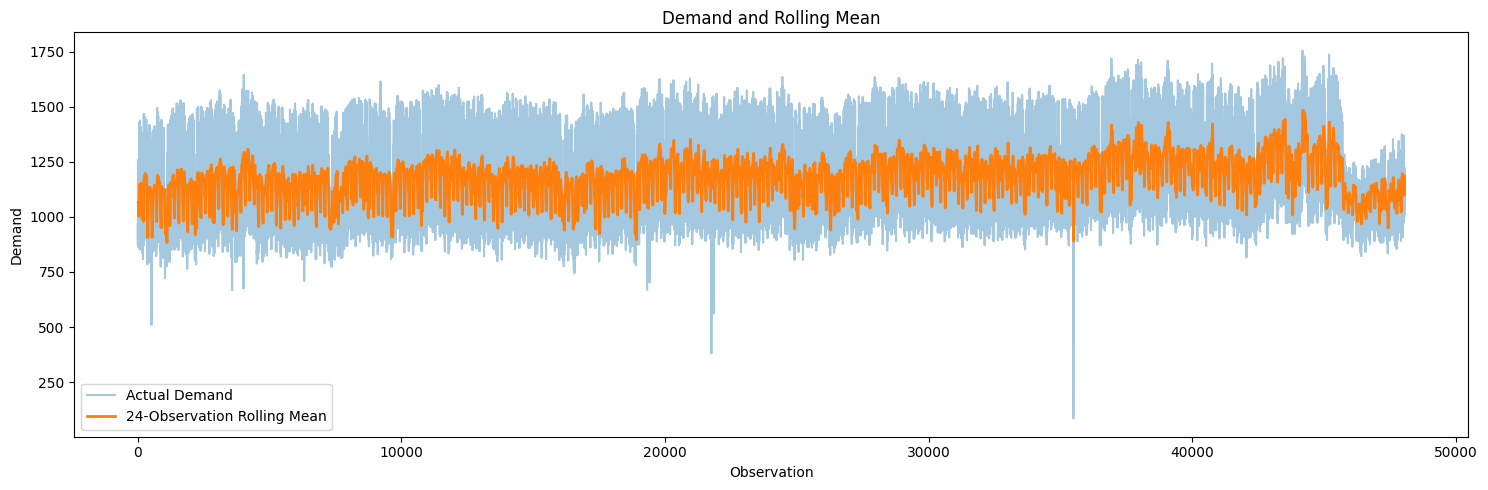

In [24]:
# rolling mean and std
df["demand_rolling_mean"] = (
    df[TARGET]
    .rolling(window=24)
    .mean()
)

plt.figure(figsize=(15, 5))

plt.plot(
    df[TARGET],
    alpha=0.4,
    label="Actual Demand"
)

plt.plot(
    df["demand_rolling_mean"],
    linewidth=2,
    label="24-Observation Rolling Mean"
)

plt.title("Demand and Rolling Mean")
plt.xlabel("Observation")
plt.ylabel("Demand")

plt.legend()
plt.tight_layout()
plt.show()

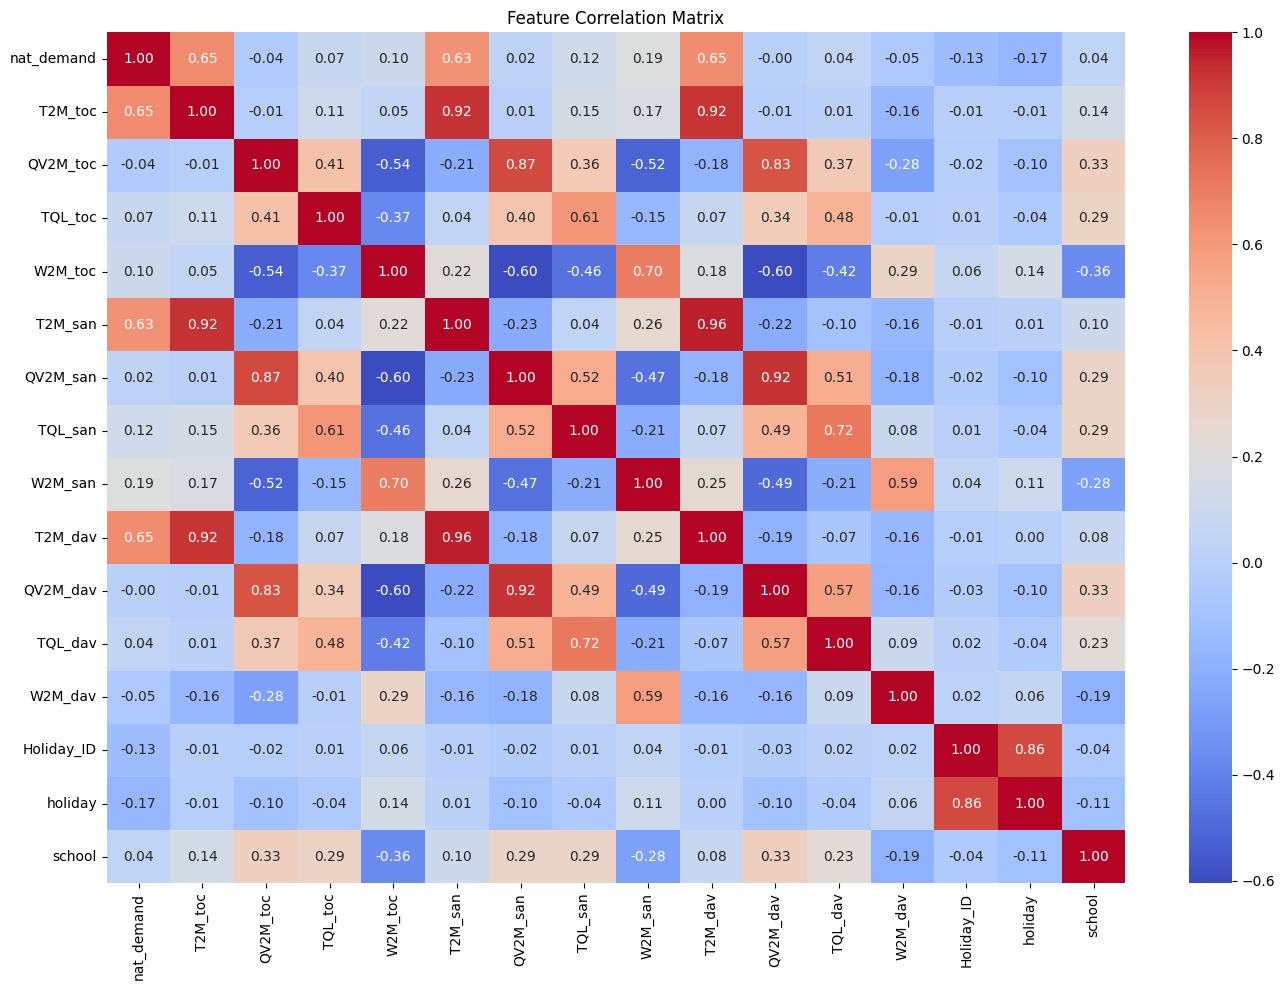

In [25]:
# Analysic corelation
correlation_matrix = df[
    [TARGET] + FEATURES
].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [26]:
# corelation rank
target_correlations = (
    correlation_matrix[TARGET]
    .sort_values(
        ascending=False
    )
)

print(target_correlations)

nat_demand    1.000000
T2M_toc       0.652811
T2M_dav       0.648279
T2M_san       0.627024
W2M_san       0.191796
TQL_san       0.119038
W2M_toc       0.098435
TQL_toc       0.073109
TQL_dav       0.042037
school        0.040044
QV2M_san      0.022172
QV2M_dav     -0.002117
QV2M_toc     -0.036706
W2M_dav      -0.054802
Holiday_ID   -0.129834
holiday      -0.165673
Name: nat_demand, dtype: float64


In [27]:
# FEATURE ENGINEERING
# creating lag features 
         # this presents the previous observation

df["lag_1"] = df[TARGET].shift(1)
df["lag_2"] = df[TARGET].shift(2)
df["lag_3"] = df[TARGET].shift(3)
df["lag_6"] = df[TARGET].shift(6)
df["lag_12"] = df[TARGET].shift(12)
df["lag_24"] = df[TARGET].shift(24)
df["lag_48"] = df[TARGET].shift(48)
df["lag_168"] = df[TARGET].shift(168)         

In [28]:
# Rolling  features 

df["rolling_mean_6"] = (
    df[TARGET]
    .shift(1)
    .rolling(6)
    .mean()
)

df["rolling_mean_12"] = (
    df[TARGET]
    .shift(1)
    .rolling(12)
    .mean()
)

df["rolling_mean_24"] = (
    df[TARGET]
    .shift(1)
    .rolling(24)
    .mean()
)

df["rolling_std_24"] = (
    df[TARGET]
    .shift(1)
    .rolling(24)
    .std()
)

In [29]:
# Demand change features
df["demand_change_1"] = (
    df[TARGET]
    .diff(1)
)

df["demand_change_24"] = (
    df[TARGET]
    .diff(24)
)

In [30]:
# removing rows with lag

df = df.dropna().reset_index(drop=True)

print("Shape after feature engineering:", df.shape)

Shape after feature engineering: (47880, 32)


In [31]:
# Final mean and std features

MODEL_FEATURES = FEATURES + [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_6",
    "rolling_mean_12",
    "rolling_mean_24",
    "rolling_std_24",
    "demand_change_1",
    "demand_change_24"
]

print("Total model features:", len(MODEL_FEATURES))

print("\nFeatures:")
for feature in MODEL_FEATURES:
    print("-", feature)



Total model features: 29

Features:
- T2M_toc
- QV2M_toc
- TQL_toc
- W2M_toc
- T2M_san
- QV2M_san
- TQL_san
- W2M_san
- T2M_dav
- QV2M_dav
- TQL_dav
- W2M_dav
- Holiday_ID
- holiday
- school
- lag_1
- lag_2
- lag_3
- lag_6
- lag_12
- lag_24
- lag_48
- lag_168
- rolling_mean_6
- rolling_mean_12
- rolling_mean_24
- rolling_std_24
- demand_change_1
- demand_change_24


In [32]:
# Spliting Time series

split_index = int(len(df) * 0.80)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print("Total:", len(df))
print("Training:", len(train))
print("Testing:", len(test))

Total: 47880
Training: 38304
Testing: 9576


In [33]:
# Prepare X and y for training and testing

X_train = train[MODEL_FEATURES]
y_train = train[TARGET]

X_test = test[MODEL_FEATURES]
y_test = test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (38304, 29)
y_train: (38304,)
X_test: (9576, 29)
y_test: (9576,)


In [34]:
# Previous value baseline 
baseline_predictions = test["lag_1"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_mape = (
    mean_absolute_percentage_error(
        y_test,
        baseline_predictions
    ) * 100
)

print("Baseline Performance")
print("--------------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("MAPE:", baseline_mape, "%")

Baseline Performance
--------------------
MAE : 42.81874569757728
RMSE: 55.548097044274115
MAPE: 3.511079302091031 %


In [35]:
## Random Forest Model

forecast_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

forecast_model.fit(
    X_train,
    y_train
)

print("Random Forest forecasting model trained successfully.")

Random Forest forecasting model trained successfully.


In [36]:
# Predictions 
y_pred = forecast_model.predict(X_test)

print("Predictions generated:", len(y_pred))

Predictions generated: 9576


In [37]:
# Evaluation function

def evaluate_regression_model(
    y_true,
    predictions,
    model_name="Model"
):
    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    mape = (
        mean_absolute_percentage_error(
            y_true,
            predictions
        ) * 100
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    results = {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2
    }

    return results

In [38]:
# evaluate Random Forest Model

rf_results = evaluate_regression_model(
    y_test,
    y_pred,
    "Random Forest"
)

rf_results

{'Model': 'Random Forest',
 'MAE': 1.3334734443043597,
 'RMSE': np.float64(3.867083191672265),
 'MAPE (%)': 0.10348021702077081,
 'R2': 0.9995677396169311}

In [39]:
# Baseline vs Random Forest Comparison

baseline_results = {
    "Model": "Previous Value Baseline",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "MAPE (%)": baseline_mape,
    "R2": r2_score(
        y_test,
        baseline_predictions
    )
}

comparison = pd.DataFrame([
    baseline_results,
    rf_results
])

comparison

,Model,MAE,RMSE,MAPE (%),R2
0,Previous Value Baseline,42.818746,55.548097,3.511079,0.910810
1,Random Forest,1.333473,3.867083,0.103480,0.999568


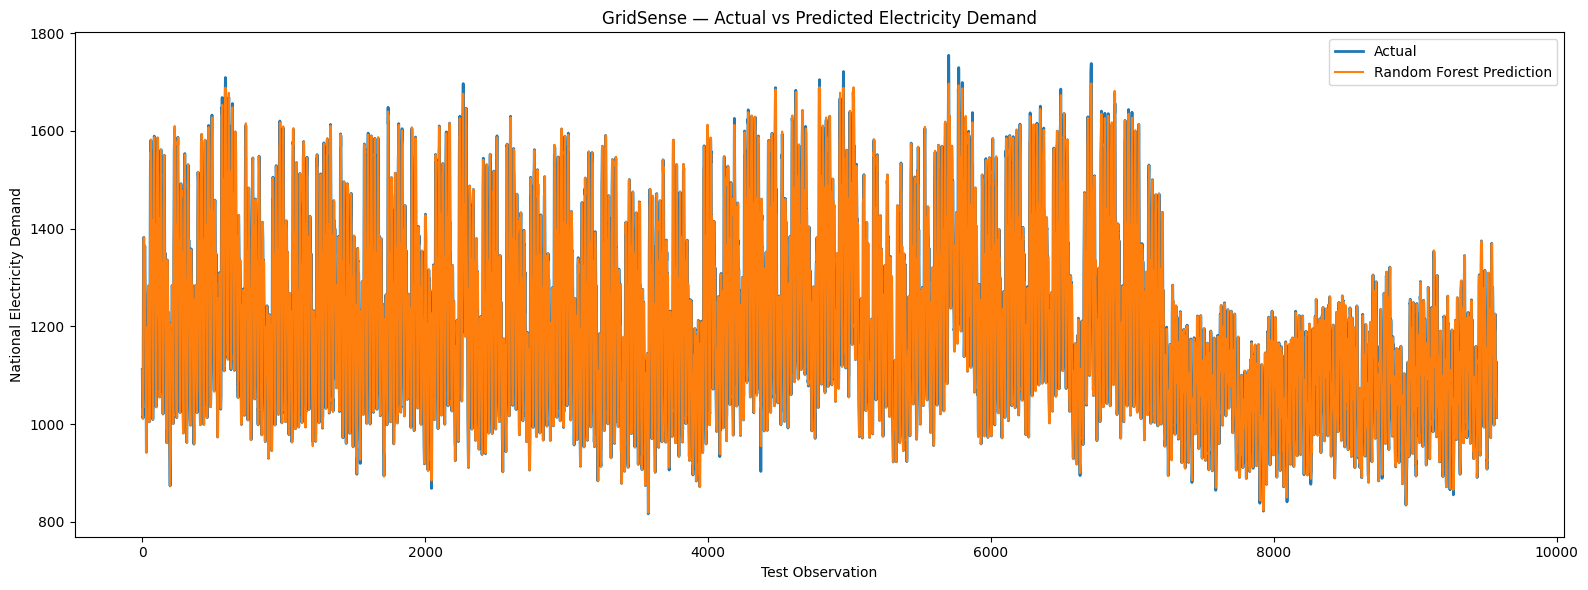

In [40]:
# plot Actual vs Predicted

plt.figure(figsize=(16, 6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_pred,
    label="Random Forest Prediction",
    linewidth=1.5
)

plt.title(
    "GridSense — Actual vs Predicted Electricity Demand"
)

plt.xlabel("Test Observation")
plt.ylabel("National Electricity Demand")

plt.legend()
plt.tight_layout()
plt.show()

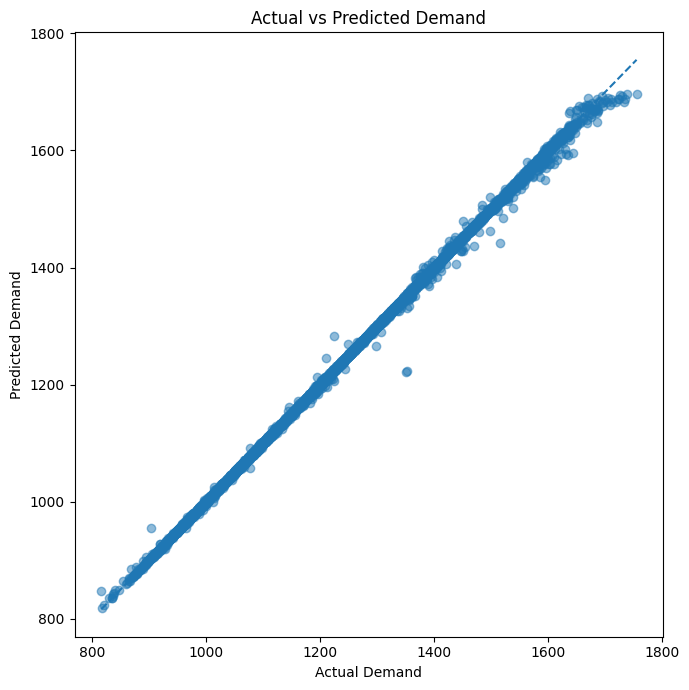

In [41]:
# prediction by scatter plot
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")

plt.title(
    "Actual vs Predicted Demand"
)

plt.tight_layout()
plt.show()

In [42]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": MODEL_FEATURES,
    "Importance": forecast_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
15,lag_1,0.858837
27,demand_change_1,0.081711
22,lag_168,0.056624
28,demand_change_24,0.001536
21,lag_48,0.000238
16,lag_2,0.000191
8,T2M_dav,0.000176
26,rolling_std_24,0.000101
20,lag_24,0.000079
24,rolling_mean_12,0.000075


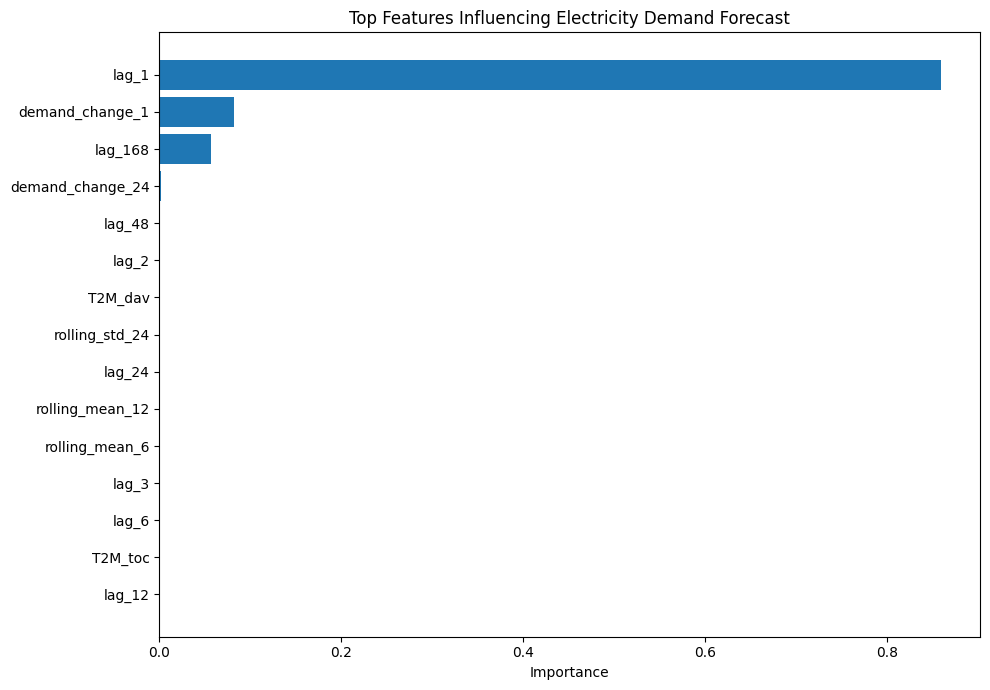

In [43]:
# plotting FI
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title(
    "Top Features Influencing Electricity Demand Forecast"
)

plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [44]:
# ANOMALY DETECTION
# Anomaly features

ANOMALY_FEATURES = [
    TARGET,
    "lag_1",
    "lag_24",
    "rolling_mean_24",
    "rolling_std_24",
    "demand_change_1",
    "demand_change_24"
]

X_anomaly = df[ANOMALY_FEATURES].copy()

print(X_anomaly.shape)


(47880, 7)


In [45]:
## Train Isolation Forest Model

anomaly_model = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

anomaly_model.fit(
    X_anomaly
)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [46]:
# Genearte anomaly predictions
df["anomaly_prediction"] = (
    anomaly_model.predict(X_anomaly)
)

In [47]:
# labels in read format
df["anomaly"] = (
    df["anomaly_prediction"]
    .map({
        1: "Normal",
        -1: "Anomaly"
    })
)

df["anomaly"].value_counts()

anomaly
Normal     46922
Anomaly      958
Name: count, dtype: int64

In [48]:
# percentage of anomalies

anomaly_count = (
    df["anomaly"] == "Anomaly"
).sum()

total_count = len(df)

anomaly_percentage = (
    anomaly_count /
    total_count *
    100
)

print("Total observations:", total_count)
print("Detected anomalies:", anomaly_count)
print(
    f"Anomaly percentage: {anomaly_percentage:.2f}%"
)

Total observations: 47880
Detected anomalies: 958
Anomaly percentage: 2.00%


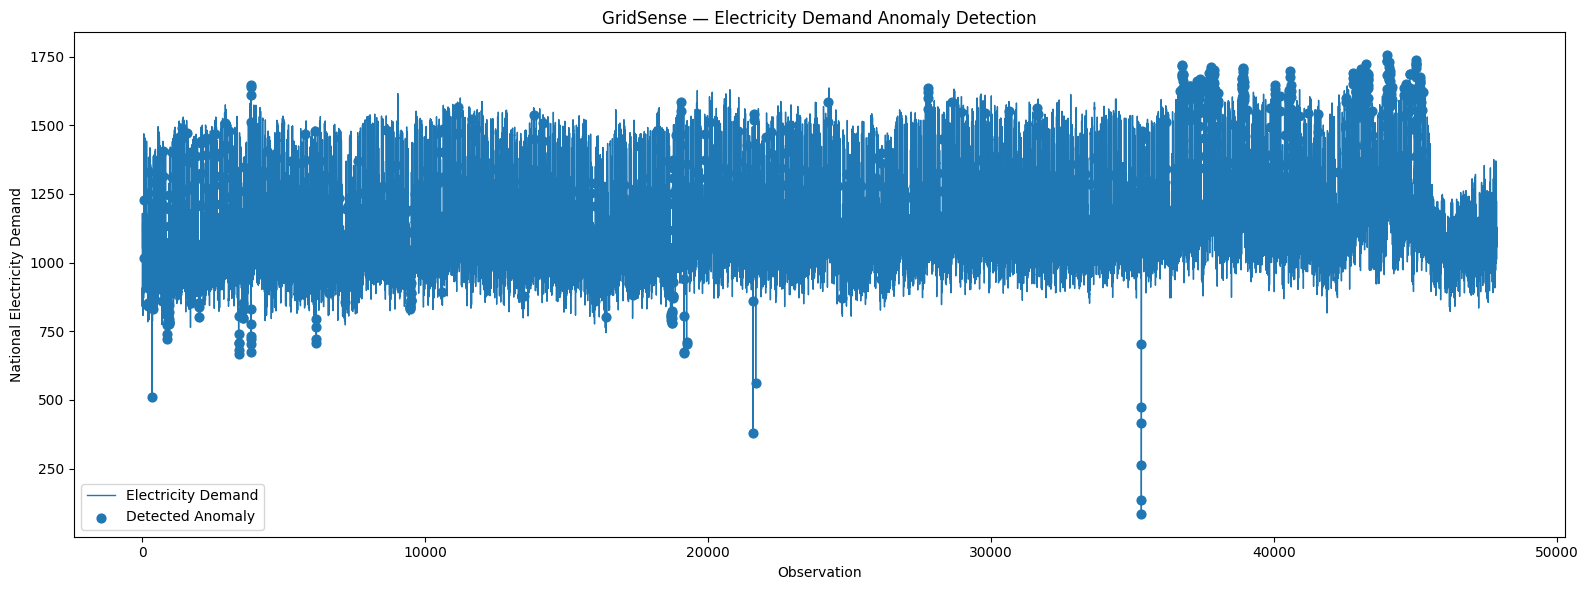

In [49]:
# Visualizing Anomalies

normal_data = df[
    df["anomaly"] == "Normal"
]

anomaly_data = df[
    df["anomaly"] == "Anomaly"
]

plt.figure(figsize=(16, 6))

plt.plot(
    df.index,
    df[TARGET],
    linewidth=1,
    label="Electricity Demand"
)

plt.scatter(
    anomaly_data.index,
    anomaly_data[TARGET],
    s=40,
    label="Detected Anomaly"
)

plt.title(
    "GridSense — Electricity Demand Anomaly Detection"
)

plt.xlabel("Observation")
plt.ylabel("National Electricity Demand")

plt.legend()
plt.tight_layout()
plt.show()

In [50]:
# inspect anomalies 

anomaly_report = anomaly_data[
    [
        TARGET,
        "lag_1",
        "lag_24",
        "rolling_mean_24",
        "rolling_std_24",
        "demand_change_1",
        "demand_change_24"
    ]
].copy()

anomaly_report.head(20)

,nat_demand,lag_1,lag_24,rolling_mean_24,rolling_std_24,demand_change_1,demand_change_24
54,1018.3418,903.8017,813.1819,992.549542,91.504593,114.5401,205.1599
55,1228.5670,1018.3418,873.8010,1001.097871,83.228286,210.2252,354.7660
199,850.1076,784.1150,1075.3486,987.394658,123.063290,65.9926,-225.2410
215,921.9623,854.4974,891.4272,906.161579,72.781065,67.4649,30.5351
219,840.0504,850.4627,824.3757,910.140175,70.971028,-10.4123,15.6747
220,852.0383,840.0504,815.4005,910.793288,70.215566,11.9879,36.6378
221,907.9800,852.0383,785.2751,912.319862,68.426929,55.9417,122.7049
222,977.8589,907.9800,784.1150,917.432567,62.881093,69.8789,193.7439
223,1163.8845,977.8589,850.1076,925.505229,57.201578,186.0256,313.7769
224,1252.6120,1163.8845,900.5203,938.579267,72.918661,88.7275,352.0917


In [51]:
# anomaly score

df["anomaly_score"] = (
    anomaly_model
    .decision_function(X_anomaly)
)

df[
    [
        TARGET,
        "anomaly",
        "anomaly_score"
    ]
].head()

,nat_demand,anomaly,anomaly_score
0,906.9580,Normal,0.086198
1,863.5135,Normal,0.063601
2,848.4447,Normal,0.061225
3,839.8821,Normal,0.050605
4,847.1073,Normal,0.047304


In [52]:
# Sort most unusual obsv

most_unusual = (
    df
    .sort_values(
        "anomaly_score"
    )
    [
        [
            TARGET,
            "anomaly_score",
            "anomaly"
        ]
    ]
    .head(20)
)

most_unusual

,nat_demand,anomaly_score,anomaly
35318,417.4492,-0.111121,Anomaly
21588,861.7986,-0.111110,Anomaly
35319,475.8024,-0.105259,Anomaly
35317,263.6183,-0.103429,Anomaly
223,1163.8845,-0.084238,Anomaly
35320,1062.2346,-0.081607,Anomaly
21686,972.4420,-0.080982,Anomaly
44030,1384.5787,-0.080029,Anomaly
35338,1450.0487,-0.078628,Anomaly
35316,135.7636,-0.077138,Anomaly


In [53]:
## using shap for explainability

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [54]:
## shap explainer

explainer = shap.TreeExplainer(
    forecast_model
)

In [55]:
## Calculation Shap Values
sample_size = min(
    1000,
    len(X_test)
)

X_shap = X_test.sample(
    sample_size,
    random_state=42
)

shap_values = explainer.shap_values(
    X_shap
)

print(
    "SHAP values calculated for:",
    len(X_shap),
    "observations"
)


SHAP values calculated for: 1000 observations


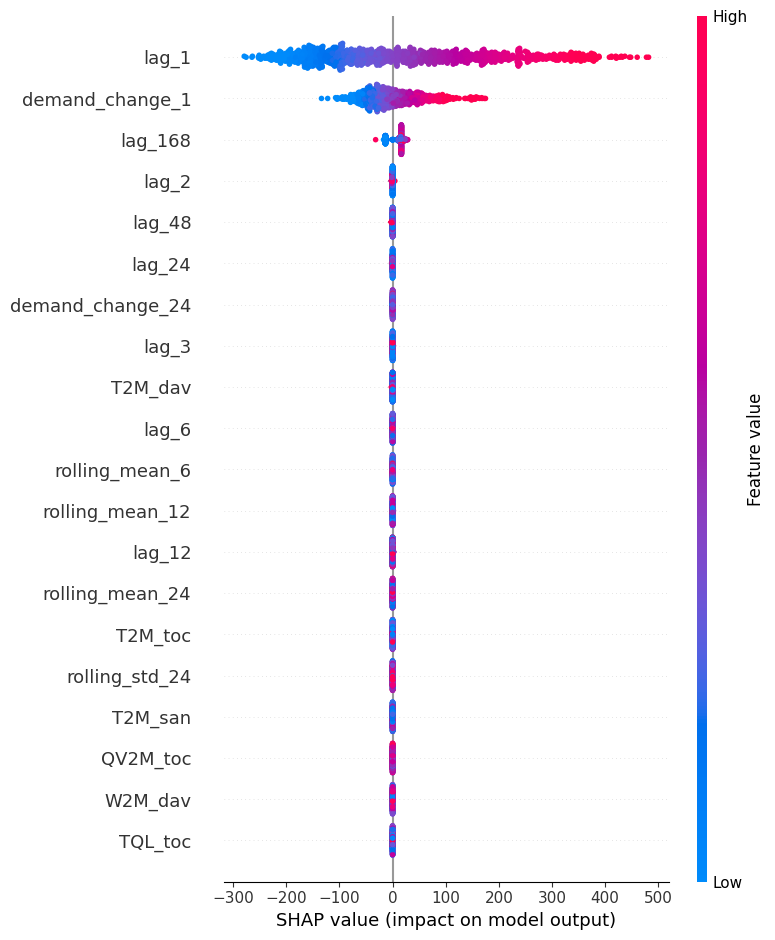

In [56]:
# shap summary 

shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

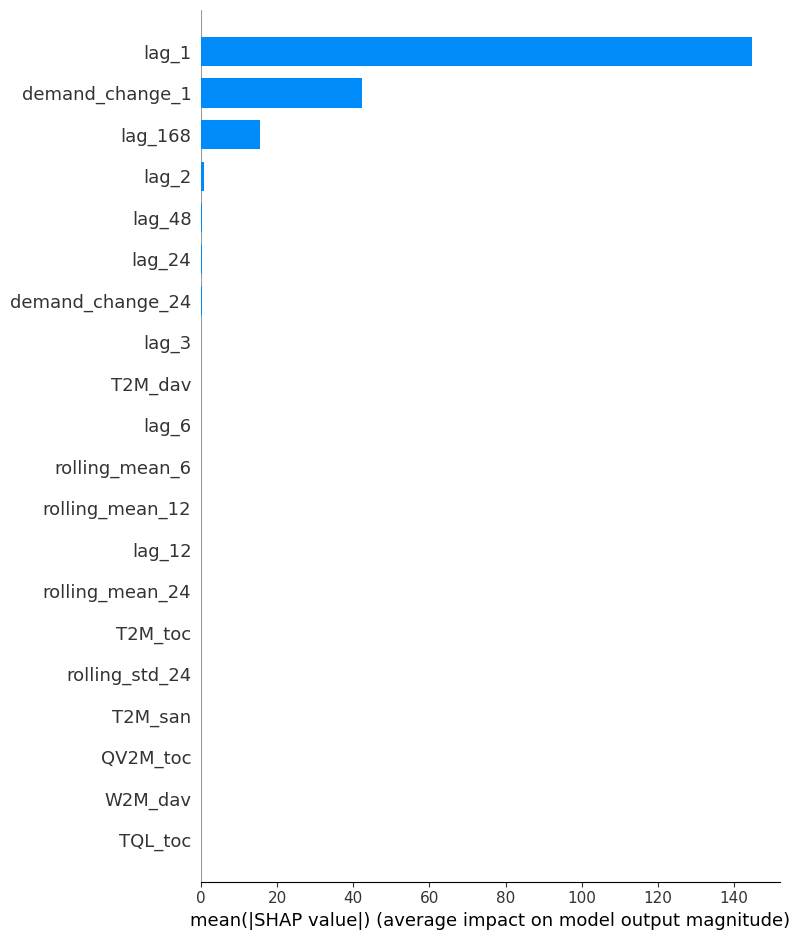

In [58]:
# shap summary plot

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=True
)

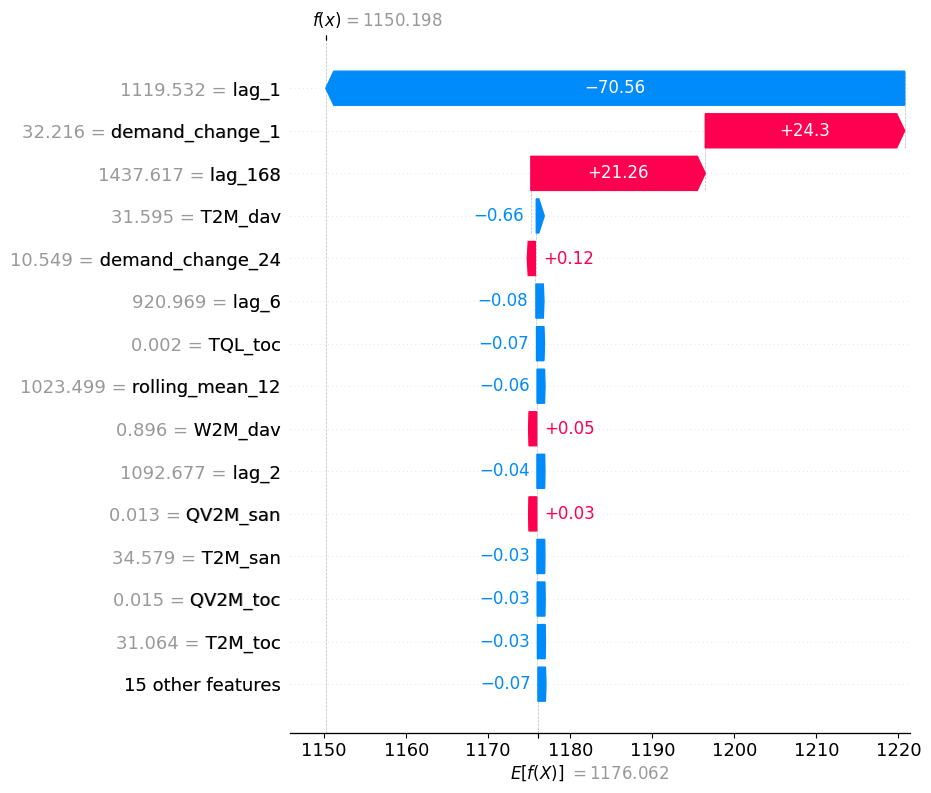

In [59]:
# obsv and explain 1 prediction 

observation_index = 0

single_explanation = shap.Explanation(
    values=shap_values[observation_index],
    base_values=explainer.expected_value,
    data=X_shap.iloc[observation_index],
    feature_names=X_shap.columns
)

shap.plots.waterfall(
    single_explanation,
    max_display=15
)

In [60]:
# saving forecast model

joblib.dump(
    forecast_model,
    os.path.join(
        MODEL_DIR,
        "forecast_model.pkl"
    )
)

print("Forecast model saved.")

Forecast model saved.


In [61]:
## save anomaly model
joblib.dump(
    anomaly_model,
    os.path.join(
        MODEL_DIR,
        "anomaly_model.pkl"
    )
)

print("Anomaly model saved.")

Anomaly model saved.


In [62]:
## Saving feature list
joblib.dump(
    MODEL_FEATURES,
    os.path.join(
        MODEL_DIR,
        "feature_columns.pkl"
    )
)

joblib.dump(
    ANOMALY_FEATURES,
    os.path.join(
        MODEL_DIR,
        "anomaly_features.pkl"
    )
)

print("Feature lists saved.")

Feature lists saved.


In [63]:
# Save processed data
df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "gridsense_processed.csv"
    ),
    index=False
)

print("Processed dataset saved.")

Processed dataset saved.


In [64]:
# save forecasting results

forecast_results = test.copy()

forecast_results["predicted_demand"] = y_pred

forecast_results["absolute_error"] = (
    np.abs(
        forecast_results[TARGET]
        -
        forecast_results["predicted_demand"]
    )
)

forecast_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "forecast_results.csv"
    ),
    index=False
)

print("Forecast results saved.")

Forecast results saved.


In [65]:
# save anomaly results

anomaly_results = df[
    [
        TARGET,
        "anomaly",
        "anomaly_prediction",
        "anomaly_score"
    ]
].copy()

anomaly_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "anomaly_results.csv"
    ),
    index=False
)

print("Anomaly results saved.")

Anomaly results saved.


In [74]:
# PROPHET = a dedicated time- series model

! pip install prophet

  Using cached prophet-1.4.0-py3-none-win_amd64.whl.metadata (3.7 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.105-py3-none-any.whl.metadata (55 kB)
Using cached prophet-1.4.0-py3-none-win_amd64.whl (12.1 MB)
Using cached holidays-0.105-py3-none-any.whl (1.6 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)

   ---------------------------------------- 0/3 [holidays]
   ---------------------------------------- 0/3 [holidays]
   ---------------------------------------- 0/3 [holidays]
   ---------------------------------------- 0/3 [holidays]
   ---------------------------------------- 0/3 [holidays]
   ---------------------------------------- 0/3 [holidays]
   ---------------------------------------- 0/3 [holidays]
   ---------------------------------------- 0/3 [holidays]
   ---------------------------------------- 0/3 [holidays]
   ---------------------------------------- 0/3 [holidays]
   --------------------------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
from prophet import Prophet

In [79]:
# prepare prophet data

prophet_df = (
    df[[TARGET]]
    .reset_index()
    .rename(
        columns={
            df.index.name if df.index.name else "index": "ds",
            TARGET: "y"
        }
    )
)

prophet_df.head()

,ds,y
0,0,906.9580
1,1,863.5135
2,2,848.4447
3,3,839.8821
4,4,847.1073


In [81]:
# Prophet (TR-TS-SPL)

prophet_split = int(
    len(prophet_df) * 0.80
)

prophet_train = prophet_df.iloc[
    :prophet_split
].copy()

prophet_test = prophet_df.iloc[
    prophet_split:
].copy()

print(
    "Prophet training:",
    prophet_train.shape
)

print(
    "Prophet testing:",
    prophet_test.shape
)

Prophet training: (38304, 2)
Prophet testing: (9576, 2)


In [85]:
# ==============================
# TRAIN PROPHET MODEL - FIXED
# ==============================

import pandas as pd
from prophet import Prophet

# Make a copy so the original data is not changed
prophet_train = prophet_train.copy()

# -------------------------------------------------
# 1. Make sure Prophet has the correct column names
# -------------------------------------------------

# Prophet requires exactly:
# ds = datetime column
# y  = numeric target column

prophet_train.columns = ["ds", "y"]

# -------------------------------------------------
# 2. Fix date parsing
# -------------------------------------------------

# dayfirst=True prevents DD/MM/YYYY dates from
# being incorrectly interpreted as MM/DD/YYYY.
prophet_train["ds"] = pd.to_datetime(
    prophet_train["ds"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# -------------------------------------------------
# 3. Convert target to numeric
# -------------------------------------------------

prophet_train["y"] = pd.to_numeric(
    prophet_train["y"],
    errors="coerce"
)

# -------------------------------------------------
# 4. Remove invalid rows
# -------------------------------------------------

before = len(prophet_train)

prophet_train = prophet_train.dropna(
    subset=["ds", "y"]
).copy()

after = len(prophet_train)

print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning:  {after}")
print(f"Rows removed:         {before - after}")

# -------------------------------------------------
# 5. Sort chronologically
# -------------------------------------------------

prophet_train = prophet_train.sort_values("ds").reset_index(drop=True)

# -------------------------------------------------
# 6. Check Prophet training data
# -------------------------------------------------

print("\nProphet training data:")
print(prophet_train.head())

print("\nData types:")
print(prophet_train.dtypes)

print("\nShape:")
print(prophet_train.shape)

# -------------------------------------------------
# 7. Train Prophet
# -------------------------------------------------

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(prophet_train)

print("\nProphet model trained successfully.")

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


Rows before cleaning: 38304
Rows after cleaning:  38304
Rows removed:         0

Prophet training data:
                             ds         y
0 1970-01-01 00:00:00.000000000  906.9580
1 1970-01-01 00:00:00.000000001  863.5135
2 1970-01-01 00:00:00.000000002  848.4447
3 1970-01-01 00:00:00.000000003  839.8821
4 1970-01-01 00:00:00.000000004  847.1073

Data types:
ds    datetime64[ns]
y            float64
dtype: object

Shape:
(38304, 2)


15:47:32 - cmdstanpy - INFO - Chain [1] start processing
15:47:52 - cmdstanpy - INFO - Chain [1] done processing



Prophet model trained successfully.


In [86]:
# Forecast Test period

future = prophet_model.make_future_dataframe(
    periods=len(prophet_test),
    freq="H"
)

prophet_forecast = prophet_model.predict(
    future
)

prophet_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
47875,1971-02-03 20:00:00.000038303,2.066097e+14,-2.197164e+16,2.443966e+16
47876,1971-02-03 21:00:00.000038303,2.066313e+14,-2.197587e+16,2.444396e+16
47877,1971-02-03 22:00:00.000038303,2.066529e+14,-2.198015e+16,2.444825e+16
47878,1971-02-03 23:00:00.000038303,2.066745e+14,-2.198446e+16,2.445257e+16
47879,1971-02-04 00:00:00.000038303,2.066960e+14,-2.198880e+16,2.445690e+16


In [87]:
# PROPHET EVALUATION 

prophet_predictions = (
    prophet_forecast
    .tail(len(prophet_test))["yhat"]
    .values
)

prophet_true = (
    prophet_test["y"]
    .values
)

prophet_results = evaluate_regression_model(
    prophet_true,
    prophet_predictions,
    "Prophet"
)

prophet_results

{'Model': 'Prophet',
 'MAE': 103358814203652.95,
 'RMSE': np.float64(119345362869090.7),
 'MAPE (%)': 8916833661641.158,
 'R2': -4.117081862743826e+23}

In [88]:
# Final model comparison

model_results = pd.DataFrame([
    baseline_results,
    rf_results,
    prophet_results
])

model_results

,Model,MAE,RMSE,MAPE (%),R2
0,Previous Value Baseline,4.281875e+01,5.554810e+01,3.511079e+00,9.108099e-01
1,Random Forest,1.333473e+00,3.867083e+00,1.034802e-01,9.995677e-01
2,Prophet,1.033588e+14,1.193454e+14,8.916834e+12,-4.117082e+23


In [6]:
# libraries for streamlite requirement

import os
import joblib
import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px
import plotly.graph_objects as go

In [7]:
#streamlite configuration
st.set_page_config(
    page_title="GridSense",
    page_icon="⚡",
    layout="wide"
)

2026-09-27 16:40:16.829 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [8]:
import os

MODEL_DIR = "models"

print("Current working directory:")
print(os.getcwd())

print("\nModels folder exists:")
print(os.path.exists(MODEL_DIR))

print("\nFiles inside models folder:")

if os.path.exists(MODEL_DIR):
    for file in os.listdir(MODEL_DIR):
        print(" -", file)
else:
    print("ERROR: models folder not found.")
    

Current working directory:
e:\Proj 1 GridSense load forecasting

Models folder exists:
True

Files inside models folder:
 - anomaly_features.pkl
 - anomaly_model.pkl
 - feature_columns.pkl
 - forecast_model.pkl


In [10]:
MODEL_DIR = "models"
DATA_PATH = "outputs/gridsense_processed.csv"

forecast_model = joblib.load(
    os.path.join(
        MODEL_DIR,
        "forecast_model.pkl"
    )
)

anomaly_model = joblib.load(
    os.path.join(
        MODEL_DIR,
        "anomaly_model.pkl"
    )
)

MODEL_FEATURES = joblib.load(
    os.path.join(
        MODEL_DIR,
        "feature_columns.pkl"
    )
)

ANOMALY_FEATURES = joblib.load(
    os.path.join(
        MODEL_DIR,
        "anomaly_features.pkl"
    )
)

df = pd.read_csv(
    DATA_PATH
)

In [12]:
# KPI CARDS

total_observations = len(df)

average_demand = df["nat_demand"].mean()

maximum_demand = df["nat_demand"].max()

anomaly_count = (
    df["anomaly"] == "Anomaly"
).sum()

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Total Observations",
    f"{total_observations:,}"
)

col2.metric(
    "Average Demand",
    f"{average_demand:,.2f}"
)

col3.metric(
    "Peak Demand",
    f"{maximum_demand:,.2f}"
)

col4.metric(
    "Detected Anomalies",
    f"{anomaly_count:,}"
)

2026-09-27 16:47:51.506 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:47:51.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:47:51.510 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:47:51.512 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:47:51.513 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:47:51.514 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:47:51.515 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:47:51.516 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [13]:
# DEMAND CHART

st.subheader("📈 Electricity Demand")

fig = px.line(
    df,
    y="nat_demand",
    title="National Electricity Demand"
)

fig.update_layout(
    xaxis_title="Observation",
    yaxis_title="Demand"
)

st.plotly_chart(
    fig,
    use_container_width=True
)

2026-09-27 16:48:34.647 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:48:34.647 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:48:34.647 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:48:34.867 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-27 16:48:34.882 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:48:34.883 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:48:34.889 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [14]:
# ANOMALY CHART 

st.subheader("🚨 Anomaly Detection")

plot_df = df.copy()

plot_df["Anomaly Value"] = np.where(
    plot_df["anomaly"] == "Anomaly",
    plot_df["nat_demand"],
    np.nan
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=plot_df["nat_demand"],
        mode="lines",
        name="Demand"
    )
)

fig.add_trace(
    go.Scatter(
        y=plot_df["Anomaly Value"],
        mode="markers",
        name="Anomaly"
    )
)

fig.update_layout(
    xaxis_title="Observation",
    yaxis_title="Demand",
    title="Detected Electricity Demand Anomalies"
)

st.plotly_chart(
    fig,
    use_container_width=True
)

2026-09-27 16:49:28.011 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:49:28.013 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:49:28.013 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:49:28.038 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-27 16:49:28.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:49:28.056 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:49:28.061 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [15]:
# SHOW ANAOMALY TABLE

st.subheader("🔎 Detected Anomalies")

anomaly_table = df[
    df["anomaly"] == "Anomaly"
][
    [
        "nat_demand",
        "anomaly_score"
    ]
]

st.dataframe(
    anomaly_table,
    use_container_width=True
)

2026-09-27 16:50:05.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:50:05.221 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:50:05.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:50:05.255 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-27 16:50:05.303 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:50:05.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:50:05.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [16]:
# FEATURE IMPORTANCE

importance_df = pd.DataFrame({
    "Feature": MODEL_FEATURES,
    "Importance": forecast_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=True
    )
)

fig = px.bar(
    importance_df.tail(15),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top Forecasting Features"
)

st.plotly_chart(
    fig,
    use_container_width=True
)

2026-09-27 16:50:32.856 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-27 16:50:32.856 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:50:32.856 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:50:32.864 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:50:32.864 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:50:32.866 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [17]:
# DATA TABLE

st.subheader("📊 Processed Dataset")

st.dataframe(
    df.tail(100),
    use_container_width=True
)

2026-09-27 16:51:41.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:51:41.939 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:51:41.942 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:51:41.947 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-27 16:51:41.972 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:51:41.974 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 16:51:41.976 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()